# Simulations I: scoring an $S_1$ speaker -- figures and tables

Notation follows `docs/report.typ`.

**Per-round score** $s^{(t)}$ -- the surprisal score of the single utterance heard at round $t$:

| report | meaning | parquet column |
|---|---|---|
| $\mathrm{surp}_1^{(t)}$ | prior predictive surprisal | `surp2_score` |
| $\mathrm{surp}_2^{(t)}$ | posterior predictive surprisal | `sus1_score` |

**Suspicion score** $\mathrm{sus}^{(T)}$ -- the *running mean* of those per-round scores, i.e. the
accumulated statistic the sequential test compares against its boundary:

$$\mathrm{sus}^{(T)} = \frac{1}{T}\sum_{t=1}^{T} s^{(t)},
\qquad
\bar\sigma^{2,(T)} = \frac{1}{T}\sum_{t=1}^{T} \sigma^{2,(t)},
\qquad
\tau = \min\Big\{t : \mathrm{sus}^{(t)} > c\,\bar\sigma^{(t)}/\sqrt{t}\Big\}.$$

| quantity | parquet column |
|---|---|
| $\mathrm{sus}^{(T)}$ for $\mathrm{surp}_1$ / $\mathrm{surp}_2$ | `surp2_Sus` / `sus1_Sus` |
| $\bar\sigma^{2,(T)}$ for $\mathrm{surp}_1$ / $\mathrm{surp}_2$ | `surp2_sigma_bar2` / `sus1_sigma_bar2` |

**Setting.** An $S_1$ speaker with true goal $\psi^\star \in \{\mathrm{inf}, \mathrm{pers}^+, \mathrm{pers}^-\}$
and rationality $\alpha$ talks for 150 rounds to a credulous $L_1^{\mathrm{cred}}$ that computes both
scores every round but never switches, so the sequential test can be evaluated offline on the saved runs
for any boundary $c$. Grid: $\theta^\star \in \{0.1, \dots, 0.9\}$,
$\alpha \in \{1, 1.5, 2, 2.5, 3, 4, 5, 7, 10, 15, 20\}$, 200 runs per cell (297 cells, 59,400 runs).

**Data sources.** Three, all lossless:

1. `results/full_sweep_v2/trajectories` -- raw per-simulation, per-round rows (8.9M). Used wherever a
   per-round quantity is needed at the reference $\alpha$.
2. `results/full_sweep_v2/agg/runs.parquet` -- one row per simulation: $\mathrm{sus}^{(150)}$ and the
   crossing round $\tau$ for every $(\mathrm{score}, c)$.
3. `results/full_sweep_v2/agg/panels_{S,V}_{score}.parquet` -- dense $(59{,}400 \times 150)$ matrices of
   $S_t = t\,\mathrm{sus}^{(t)}$ and $V_t = t\,\bar\sigma^{2,(t)}$, in `runs.parquet` row order. Any
   boundary can be scored against them exactly, since
   $\mathrm{sus}^{(t)} > c\,\bar\sigma^{(t)}/\sqrt{t} \iff S_t > c\sqrt{V_t}$.

Nothing is re-simulated and no stored file is modified. Figures are written to
`results/report/figures/`, tables to `results/report/tables/`.

**Conventions.** $\alpha = 3$ and $c = 3.5$ are the reference settings whenever one value is needed;
rates pooled over $\alpha$ exclude $\alpha = 1$. "Detected" means the running mean crossed the boundary
at some $t \le 150$, and $\tau$ is the first such $t$.

In [1]:
import math
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
from matplotlib.colors import LinearSegmentedColormap, LogNorm

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir())
if str(ROOT) not in sys.path:          # the kernel starts in notebooks/; rsa/ lives at the root
    sys.path.insert(0, str(ROOT))
TRAJ = ROOT / "results" / "full_sweep_v2" / "trajectories"
AGG = ROOT / "results" / "full_sweep_v2" / "agg"
FIGS = ROOT / "results" / "report" / "figures"
TABS = ROOT / "results" / "report" / "tables"
FIGS.mkdir(parents=True, exist_ok=True)
TABS.mkdir(parents=True, exist_ok=True)

# ---- naming: report score name -> parquet column prefix --------------------
SC_PREFIX = {"surp1": "surp2", "surp2": "sus1"}
SC_LABEL = {"surp1": r"$\mathrm{surp}_1$ (prior predictive)",
            "surp2": r"$\mathrm{surp}_2$ (posterior predictive)"}
SC_SUS_LABEL = {sc: rf"$\mathrm{{sus}}^{{(T)}}$ of {SC_LABEL[sc]}" for sc in SC_PREFIX}

# ---- fixed identity colours (as in experiments/report_figures.py) ----------
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
C_BLUE, C_ORANGE, C_VIOLET, C_MAGENTA = "#2a78d6", "#eb6834", "#4a3aa7", "#e87ba4"
SC_COL = {"surp1": C_MAGENTA, "surp2": C_BLUE}
PSI_COL = {"inf": C_BLUE, "pers+": C_ORANGE, "pers-": C_VIOLET}
PSI_LABEL = {"inf": "informative", "pers+": "persuade-up", "pers-": "persuade-down"}
PSI_LS = {"inf": "-", "pers+": "--", "pers-": (0, (1, 1.4))}
# raw trajectory label <-> aggregate-table label
PSI_RAW2AGG = {"inf": "inf", "pers+": "high", "pers-": "low"}
PSI_AGG2RAW = {v: k for k, v in PSI_RAW2AGG.items()}

# sequential ramps: for a parameter (c) and for theta*, kept off the two score hues
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#104281", "#0d366b"]
ORANGES = ["#fbd9c9", "#f5b08e", "#ef8a5e", "#eb6834", "#c94f21", "#9d3b16"]
GREYS = ["#c9c8c2", "#9a9994", "#6f6e6a", "#494844", "#0b0b0b"]
seq_blue = LinearSegmentedColormap.from_list("seqblue", BLUES)
seq_theta = LinearSegmentedColormap.from_list("seqorange", ORANGES)
seq_param = LinearSegmentedColormap.from_list("seqgrey", GREYS)
div_dprime = LinearSegmentedColormap.from_list(
    "divdp", [ORANGES[-1], ORANGES[1], "#eeede8", BLUES[1], BLUES[-1]])

# ---- reference settings ----------------------------------------------------
ALPHA = 3.0            # reference rationality
C_BOUND = 1.0          # boundary drawn on the running-mean figures
C_REF = 3.5            # reference boundary for detection rates
C_LIST = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
ALPHA_POOL_MIN = 1.5   # pooled rates exclude alpha = 1
ROUNDS = 150
THETAS_LISTENER = np.round(np.arange(0, 1.01, 0.1), 10)   # listener's 11-point theta grid
DPI = 200

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": DPI, "axes.edgecolor": INK2,
                     "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK2,
                     "ytick.color": INK2, "font.size": 9})


def save_fig(fig, name):
    fig.savefig(FIGS / name, dpi=DPI, bbox_inches="tight")
    print("saved", (FIGS / name).relative_to(ROOT))


def save_table(df, name, index=False):
    df.to_csv(TABS / name, index=index)
    print("saved", (TABS / name).relative_to(ROOT))
    return df


def style(ax):
    ax.grid(color=GRID, lw=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    return ax

## Helpers

`load_runs` pulls the raw per-simulation rows for one $(\psi^\star, \alpha)$ cell; `summarise_sus`
averages the suspicion score over simulations at each $(\theta^\star, T)$ and returns the standard error
of that mean; `plot_sus_panels` draws one panel per $\theta^\star$. `rebuild_predictive` recomputes the
credulous listener's prior predictive $P_{L_1^{\mathrm{cred}}}^{(t)}(\cdot)$ from the stored beliefs,
which is what splits $\mathrm{surp}_1$ into its two terms; it is validated against the stored score in
figure F2.

In [2]:
SCORE_COLS = [f"{px}_{k}" for px in SC_PREFIX.values()
              for k in ("score", "Sus", "sigma2", "sigma_bar2")]
BELIEF_COLS = [f"{a}_theta_{i}" for a in ("L1", "L0") for i in range(11)]


def load_runs(psi_true, alpha=ALPHA, extra=()):
    """Raw trajectory rows for one (psi_true, alpha) cell: all theta*, all sims, all rounds."""
    cols = ["theta_star", "sim_id", "round"] + SCORE_COLS + list(extra)
    tab = ds.dataset(TRAJ, format="parquet", partitioning="hive").to_table(
        columns=cols,
        filter=(pc.field("psi_true") == psi_true) & (pc.field("alpha") == alpha),
    )
    return tab.to_pandas()


def summarise_sus(runs, c=C_BOUND):
    """Mean suspicion score over simulations, its standard error, and the test boundary.

    sus_mean : mean over simulations of sus^(T)   (sus^(T) is already the running mean over rounds)
    sus_se   : sd over simulations / sqrt(n_sims) -- uncertainty of that mean, not the spread of runs
    bound    : c * sigma_bar^(T) / sqrt(T), computed per simulation then averaged over simulations
    """
    out = {}
    for sc, px in SC_PREFIX.items():
        b = c * np.sqrt(runs[f"{px}_sigma_bar2"] / runs["round"])
        g = runs.assign(_b=b).groupby(["theta_star", "round"])
        s = g[f"{px}_Sus"]
        out[sc] = pd.DataFrame({"sus_mean": s.mean(),
                                "sus_se": s.std(ddof=1) / np.sqrt(s.count()),
                                "bound": g["_b"].mean()})
    return out


def panel_grid(nrow=3, ncol=3, figsize=(12, 9), sharey=True):
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize, sharex=True, sharey=sharey)
    for ax in axes.flat:
        style(ax)
    return fig, axes


def finish_panels(fig, axes, thetas, xlabel, ylabel, handles=None, labels=None,
                  title="", subtitle="", ncol=3, legend_y=0.96, rect_top=0.93):
    axes2 = np.atleast_2d(axes)
    for ax, th in zip(axes2.flat, thetas):
        ax.set_title(rf"$\theta^\star = {th:g}$", fontsize=9)
    for ax in axes2[-1]:
        ax.set_xlabel(xlabel)
    for ax in axes2[:, 0]:
        ax.set_ylabel(ylabel)
    if handles is None:
        handles, labels = axes2[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, legend_y),
               ncol=ncol, frameon=False)
    fig.suptitle(title + ("\n" + subtitle if subtitle else ""), y=1.0)
    fig.tight_layout(rect=(0, 0, 1, rect_top))


def plot_sus_panels(stats, thetas, psi_true, n_sims, alpha=ALPHA, c=C_BOUND):
    fig, axes = panel_grid()
    for ax, th in zip(axes.flat, thetas):
        for sc in SC_PREFIX:
            d = stats[sc].loc[th]
            ax.fill_between(d.index, d["sus_mean"] - d["sus_se"], d["sus_mean"] + d["sus_se"],
                            color=SC_COL[sc], alpha=0.25, lw=0)
            ax.plot(d.index, d["sus_mean"], color=SC_COL[sc], lw=1.6, label=SC_SUS_LABEL[sc])
            ax.plot(d.index, d["bound"], color=SC_COL[sc], lw=1.2, ls="--",
                    label=(rf"boundary $c\,\bar\sigma^{{(T)}}/\sqrt{{T}}$, $c={c:g}$"
                           if sc == "surp1" else None))
        ax.axhline(0, color=INK2, lw=0.8, ls=":")
    finish_panels(fig, axes, thetas, "round $T$", r"suspicion score $\mathrm{sus}^{(T)}$",
                  title=(r"Suspicion score $\mathrm{sus}^{(T)}$ (running mean of the per-round scores)"
                         rf" -- {PSI_LABEL[psi_true]} $S_1$ speaker, $\alpha = {alpha:g}$"),
                  subtitle=rf"mean $\pm$ 1 SE over {n_sims} simulations per $\theta^\star$")
    return fig


# ---- exact reconstruction of the credulous listener's prior predictive -----
from rsa.setup import make_semantics, make_world   # noqa: E402

_world = make_world(0.5, n=1, m=7)
_sem = make_semantics(n=1)
TRUTH = np.asarray(_sem.truth_table(_world), dtype=float)                        # (n_obs, n_utt)
OBS_PROB = np.asarray(_world.obs_prob_table(list(THETAS_LISTENER)), dtype=float)  # (n_obs, n_theta)
S0_TABLE = TRUTH / TRUTH.sum(1, keepdims=True)                                   # P_S0(u | O)
EPS = 1e-12


def rebuild_predictive(L1_theta, L0_theta, u_idx, alpha, chunk=8192):
    """Realised surprisal -log P_Lc(u_obs) and entropy H(P_Lc) of the prior predictive, per round.

    Replays the S0 -> L0 -> S1 chain of rsa/ in closed form from the stored per-round beliefs:
        P_L0(O)      = sum_theta L0(theta) P(O | theta)
        P_L0(O | u) ~ P_S0(u | O) P_L0(O)
        S1(u | O)   ~ Truth(u; O) P_L0(O | u)^alpha
        P_Lc(u)      = sum_O S1(u | O) P_Lc(O),   P_Lc(O) = sum_theta L1(theta) P(O | theta)
    Their difference is surp1, which is asserted against the stored score in F2.
    """
    n = len(u_idx)
    realised = np.empty(n)
    entropy = np.empty(n)
    for a in range(0, n, chunk):
        b = min(a + chunk, n)
        l0, l1, u = L0_theta[a:b], L1_theta[a:b], u_idx[a:b]
        L0_O = OBS_PROB @ l0.T
        L0_O = (L0_O / L0_O.sum(0)).T
        L1_O = OBS_PROB @ l1.T
        L1_O = (L1_O / L1_O.sum(0)).T
        utt_prior = L0_O @ S0_TABLE
        post = S0_TABLE[None] * L0_O[:, :, None] / np.maximum(utt_prior[:, None, :], EPS)
        w = TRUTH[None] * np.power(np.maximum(post, 0.0), alpha)
        rs = w.sum(2, keepdims=True)
        S1 = np.where(rs > 0, w / np.maximum(rs, EPS), S0_TABLE[None])
        P = np.einsum("nou,no->nu", S1, L1_O)
        P = P / P.sum(1, keepdims=True)
        logP = np.log(np.maximum(P, EPS))
        entropy[a:b] = -(P * logP).sum(1)
        realised[a:b] = -logP[np.arange(b - a), u]
    return realised, entropy

## 1. Informative speaker ($\psi^\star = \mathrm{inf}$): the null

The credulous listener's model is correct here, so $\mathrm{sus}^{(T)}$ should converge to zero and stay
inside the boundary at every $\theta^\star$.

In [3]:
runs_inf = load_runs("inf")
runs_inf.groupby("theta_star").agg(n_sims=("sim_id", "nunique"), rounds=("round", "max"))

,n_sims,rounds
theta_star,,
0.1,200,150
0.2,200,150
0.3,200,150
0.4,200,150
0.5,200,150
0.6,200,150
0.7,200,150
0.8,200,150
0.9,200,150


saved results\report\figures\S17_runmean_inf.png


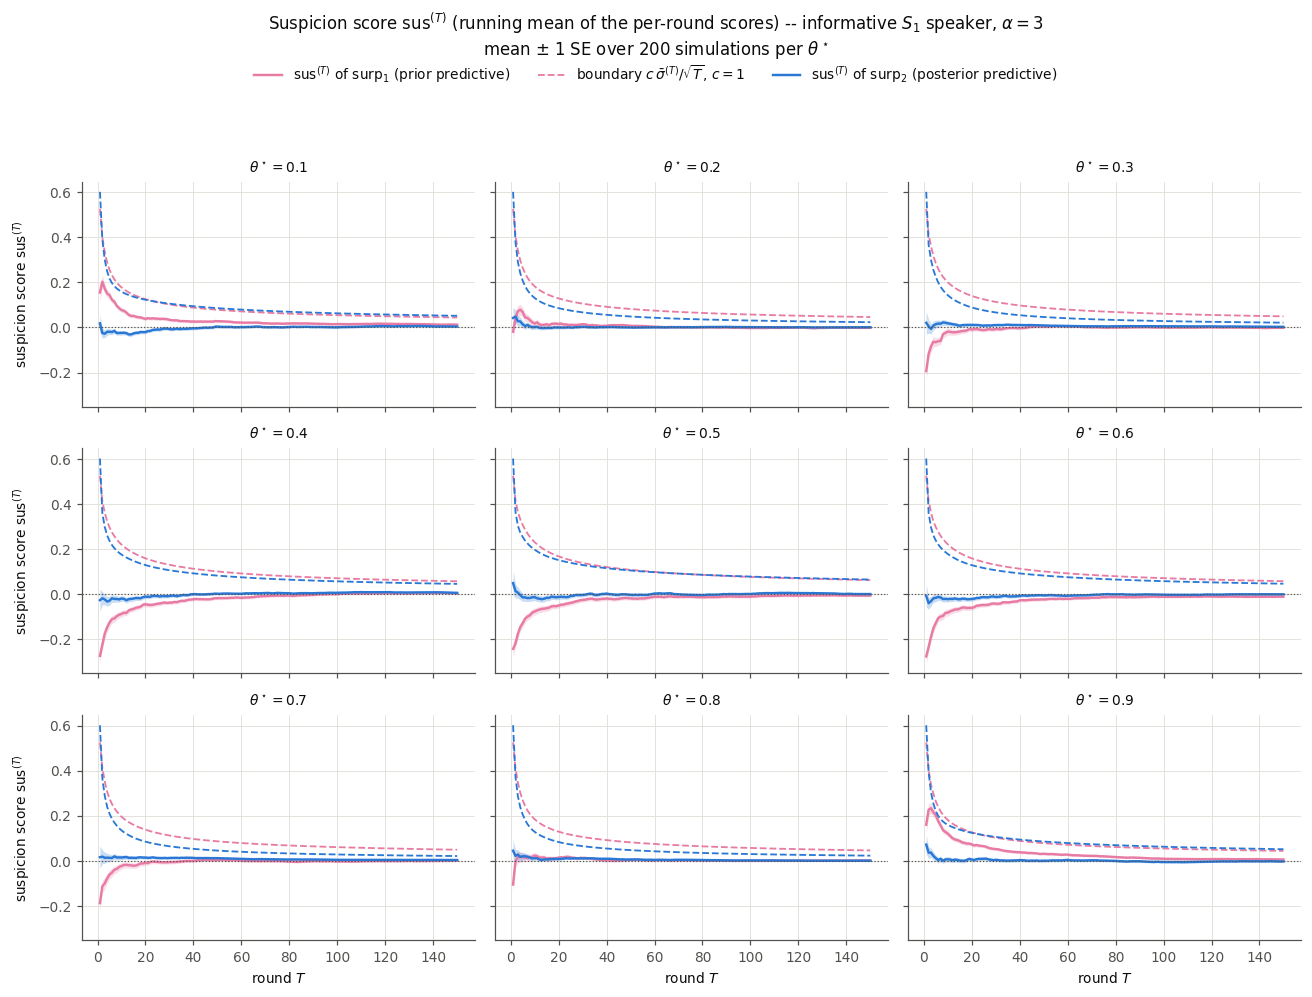

In [4]:
stats_inf = summarise_sus(runs_inf)
thetas = sorted(runs_inf["theta_star"].unique())
fig = plot_sus_panels(stats_inf, thetas, "inf", runs_inf["sim_id"].nunique())
save_fig(fig, "S17_runmean_inf.png")

## 2. Persuade-up speaker ($\psi^\star = \mathrm{pers}^+$)

Same $\alpha$ and the same credulous listener, but the speaker now maximises the literal listener's
posterior mean. The scores are still computed under the informative null, so $\mathrm{sus}^{(T)}$ should
acquire a positive mean and drift across the boundary.

saved results\report\figures\S18_runmean_pers_up.png


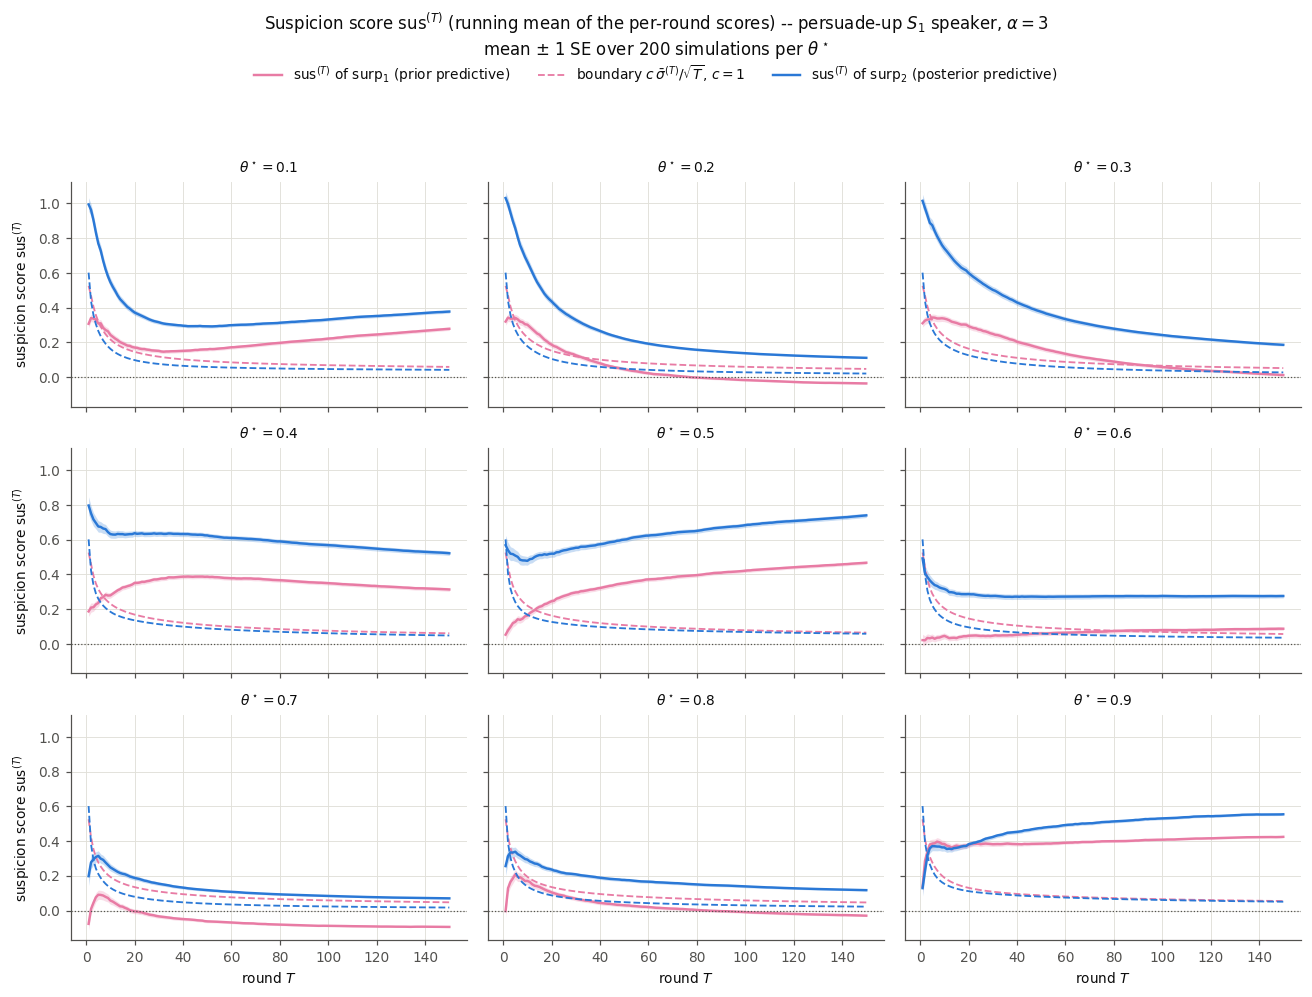

In [5]:
runs_pp = load_runs("pers+")
stats_pp = summarise_sus(runs_pp)
fig = plot_sus_panels(stats_pp, thetas, "pers+", runs_pp["sim_id"].nunique())
save_fig(fig, "S18_runmean_pers_up.png")

## 3. Run-level tables

`runs.parquet` and the $(S_t, V_t)$ panels, used by every figure below that needs all 297 cells. The
assertion checks that a crossing time recomputed from the panels reproduces the stored $\tau$ exactly for
every score and every $c$, which also confirms that panel rows are aligned with `runs.parquet`.

In [6]:
RUNS = pd.read_parquet(AGG / "runs.parquet")
PANEL_S = {sc: pd.read_parquet(AGG / f"panels_S_{px}.parquet").to_numpy()
           for sc, px in SC_PREFIX.items()}
PANEL_V = {sc: pd.read_parquet(AGG / f"panels_V_{px}.parquet").to_numpy()
           for sc, px in SC_PREFIX.items()}

RUNS["psi_raw"] = RUNS["psi_star"].map(PSI_AGG2RAW)
ALPHAS = sorted(RUNS["alpha"].unique())
IS_PERS = RUNS["psi_star"].isin(["high", "low"]).to_numpy()
IS_INF = (RUNS["psi_star"] == "inf").to_numpy()
POOLED = (RUNS["alpha"] >= ALPHA_POOL_MIN).to_numpy()
ROUND_AXIS = np.arange(1, ROUNDS + 1)


def crossed_by_T(sc, c):
    """Boolean (n_runs, 150): has sus(t) crossed c * sigma_bar(t) / sqrt(t) by round t?"""
    S, V = PANEL_S[sc], PANEL_V[sc]
    return np.maximum.accumulate((V > 0) & (S > c * np.sqrt(V)), axis=1)


def tau_from_panels(sc, c):
    """Crossing round tau (1-based), -1 if the boundary is never crossed within 150 rounds."""
    hit = crossed_by_T(sc, c)
    return np.where(hit[:, -1], hit.argmax(axis=1) + 1, -1)


def tau_stored(sc, c):
    return RUNS[f"tau_{SC_PREFIX[sc]}_c{c:g}"].to_numpy()


for _sc in SC_PREFIX:
    for _c in C_LIST:
        assert np.array_equal(tau_from_panels(_sc, _c), tau_stored(_sc, _c)), (_sc, _c)
print("panels reproduce the stored tau exactly for every score and every c in", C_LIST)
print("runs:", len(RUNS), "  panel shape:", PANEL_S["surp1"].shape)

panels reproduce the stored tau exactly for every score and every c in [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
runs: 59400   panel shape: (59400, 150)


## F1. Per-round score mean, not the running mean

`S7_per_round_mean.png`. $\mathbb{E}[s^{(t)}]$ against round $t$ (log $x$), mean $\pm$ 1 SE over the 200
runs, one panel per $\theta^\star$, both scores, all three goals, $\alpha = 3$. This is the plot behind
the running-mean figures. What to look for:

- under the informative speaker, the per-round mean of $\mathrm{surp}_1$ starts away from zero and decays
  to zero within about 20 rounds, while $\mathrm{surp}_2$ is near zero from round 1;
- under the persuasive speakers, the per-round mean of $\mathrm{surp}_2$ stays positive at every
  $\theta^\star$, while that of $\mathrm{surp}_1$ decays towards zero or below at
  $\theta^\star \in \{0.2, 0.3, 0.7, 0.8\}$.

saved results\report\figures\S7_per_round_mean.png


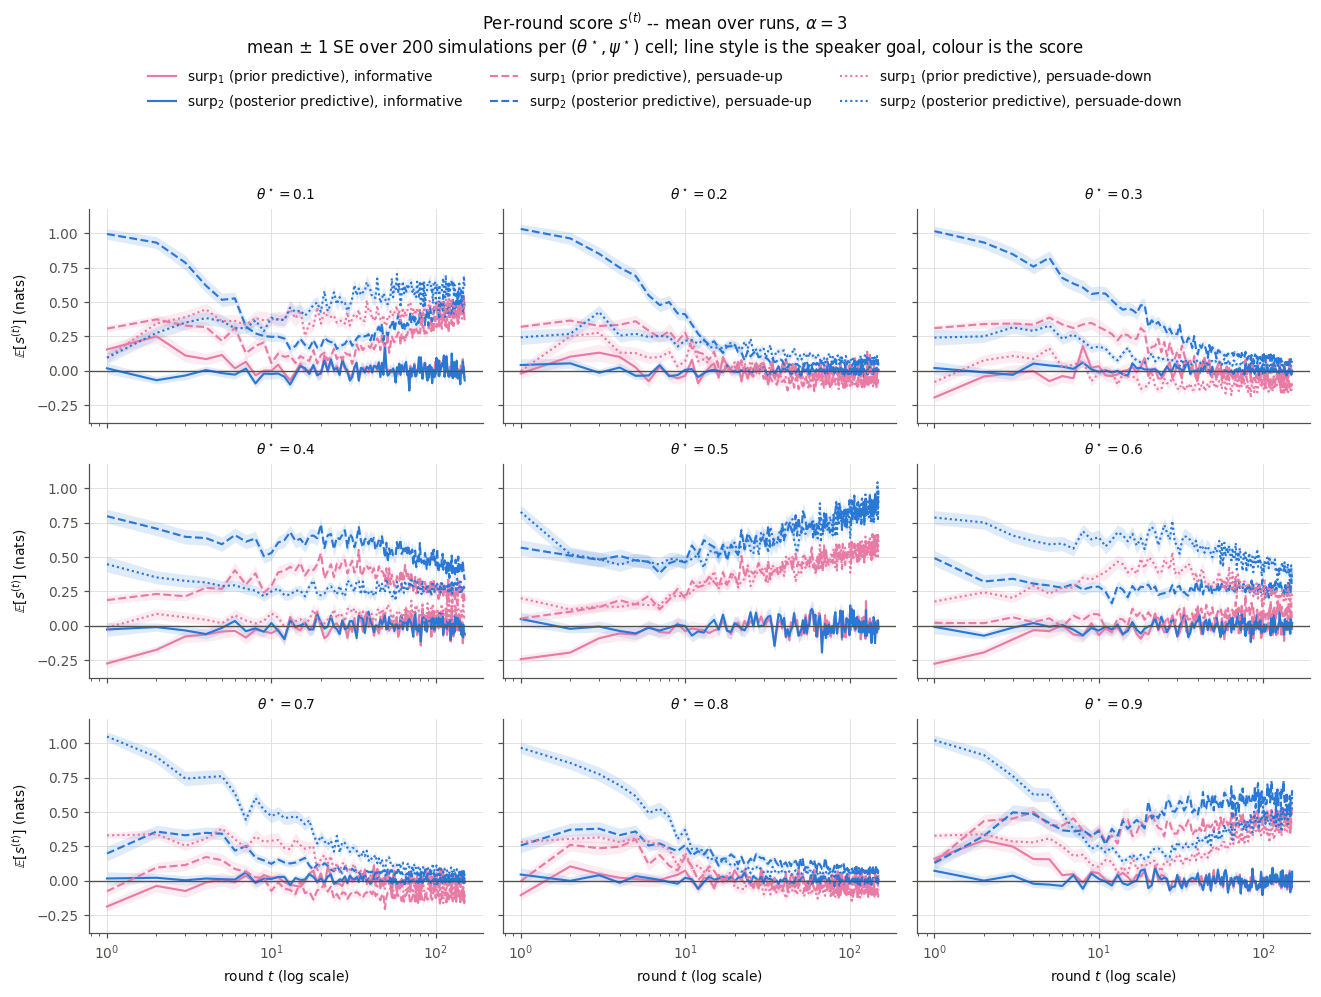

In [7]:
runs_pm = load_runs("pers-")

_rows = []
for _psi, _df in [("inf", runs_inf), ("pers+", runs_pp), ("pers-", runs_pm)]:
    _g = _df.groupby(["theta_star", "round"])
    for _sc, _px in SC_PREFIX.items():
        _s = _g[f"{_px}_score"]
        _d = pd.DataFrame({"mean": _s.mean(), "se": _s.std(ddof=1) / np.sqrt(_s.count())}).reset_index()
        _d["psi"], _d["score"] = _psi, _sc
        _rows.append(_d)
PER_ROUND = pd.concat(_rows, ignore_index=True)

fig, axes = panel_grid(figsize=(12, 9))
for ax, th in zip(axes.flat, thetas):
    for psi in PSI_LABEL:
        for sc in SC_PREFIX:
            d = PER_ROUND[(PER_ROUND["theta_star"] == th) & (PER_ROUND["psi"] == psi)
                          & (PER_ROUND["score"] == sc)]
            ax.fill_between(d["round"], d["mean"] - d["se"], d["mean"] + d["se"],
                            color=SC_COL[sc], alpha=0.14, lw=0)
            ax.plot(d["round"], d["mean"], color=SC_COL[sc], ls=PSI_LS[psi], lw=1.4,
                    label=f"{SC_LABEL[sc]}, {PSI_LABEL[psi]}")
    ax.axhline(0, color=INK2, lw=0.9)
    ax.set_xscale("log")
finish_panels(fig, axes, thetas, "round $t$ (log scale)", r"$\mathbb{E}[s^{(t)}]$ (nats)",
              title=r"Per-round score $s^{(t)}$ -- mean over runs, $\alpha = 3$",
              subtitle=r"mean $\pm$ 1 SE over 200 simulations per $(\theta^\star, \psi^\star)$ cell;"
                       " line style is the speaker goal, colour is the score",
              ncol=3, legend_y=0.955, rect_top=0.90)
save_fig(fig, "S7_per_round_mean.png")

## F2. Why $\mathrm{surp}_1$ is absorbed

`S8_surp1_absorption.png`. Persuade-up $S_1$ at $\alpha = 3$, one block per $\theta^\star$. The tall axis
shows the two terms whose difference is $\mathrm{surp}_1$: the realised surprisal
$-\log P_{L_1^{\mathrm{cred}}}^{(t)}(u^{(t)})$ and the entropy $H(P_{L_1^{\mathrm{cred}}}^{(t)})$ of the
listener's prior predictive, with the gap between them shaded. The short axis below shows the credulous
listener's posterior mean $\mathbb{E}[\theta]$ against the true $\theta^\star$ (dotted).

The two surprisal terms converge on each other, which is why $\mathrm{surp}_1 \to 0$: the belief settles
on a wrong $\theta$ under which the persuasive utterances are typical, so they stop being globally rare.

The predictive is rebuilt from the stored per-round beliefs; the assertion checks that the rebuilt
difference reproduces the stored $\mathrm{surp}_1$ score to machine precision.

In [8]:
from matplotlib.lines import Line2D

bel = load_runs("pers+", extra=("u_observed", *BELIEF_COLS))
_L1 = bel[[f"L1_theta_{i}" for i in range(11)]].to_numpy()
_L0 = bel[[f"L0_theta_{i}" for i in range(11)]].to_numpy()
_realised, _entropy = rebuild_predictive(_L1, _L0, bel["u_observed"].to_numpy(), ALPHA)

_err = np.abs((_realised - _entropy) - bel["surp2_score"].to_numpy()).max()
assert _err < 1e-9, _err
print(f"rebuilt surp1 matches the stored score to {_err:.2e} nats over {len(bel):,} rounds")

bel["realised"] = _realised
bel["entropy"] = _entropy
bel["E_theta"] = _L1 @ THETAS_LISTENER
ABS = bel.groupby(["theta_star", "round"])[["realised", "entropy", "E_theta"]].agg(["mean", "sem"])

rebuilt surp1 matches the stored score to 2.66e-15 nats over 270,000 rounds


saved results\report\figures\S8_surp1_absorption.png


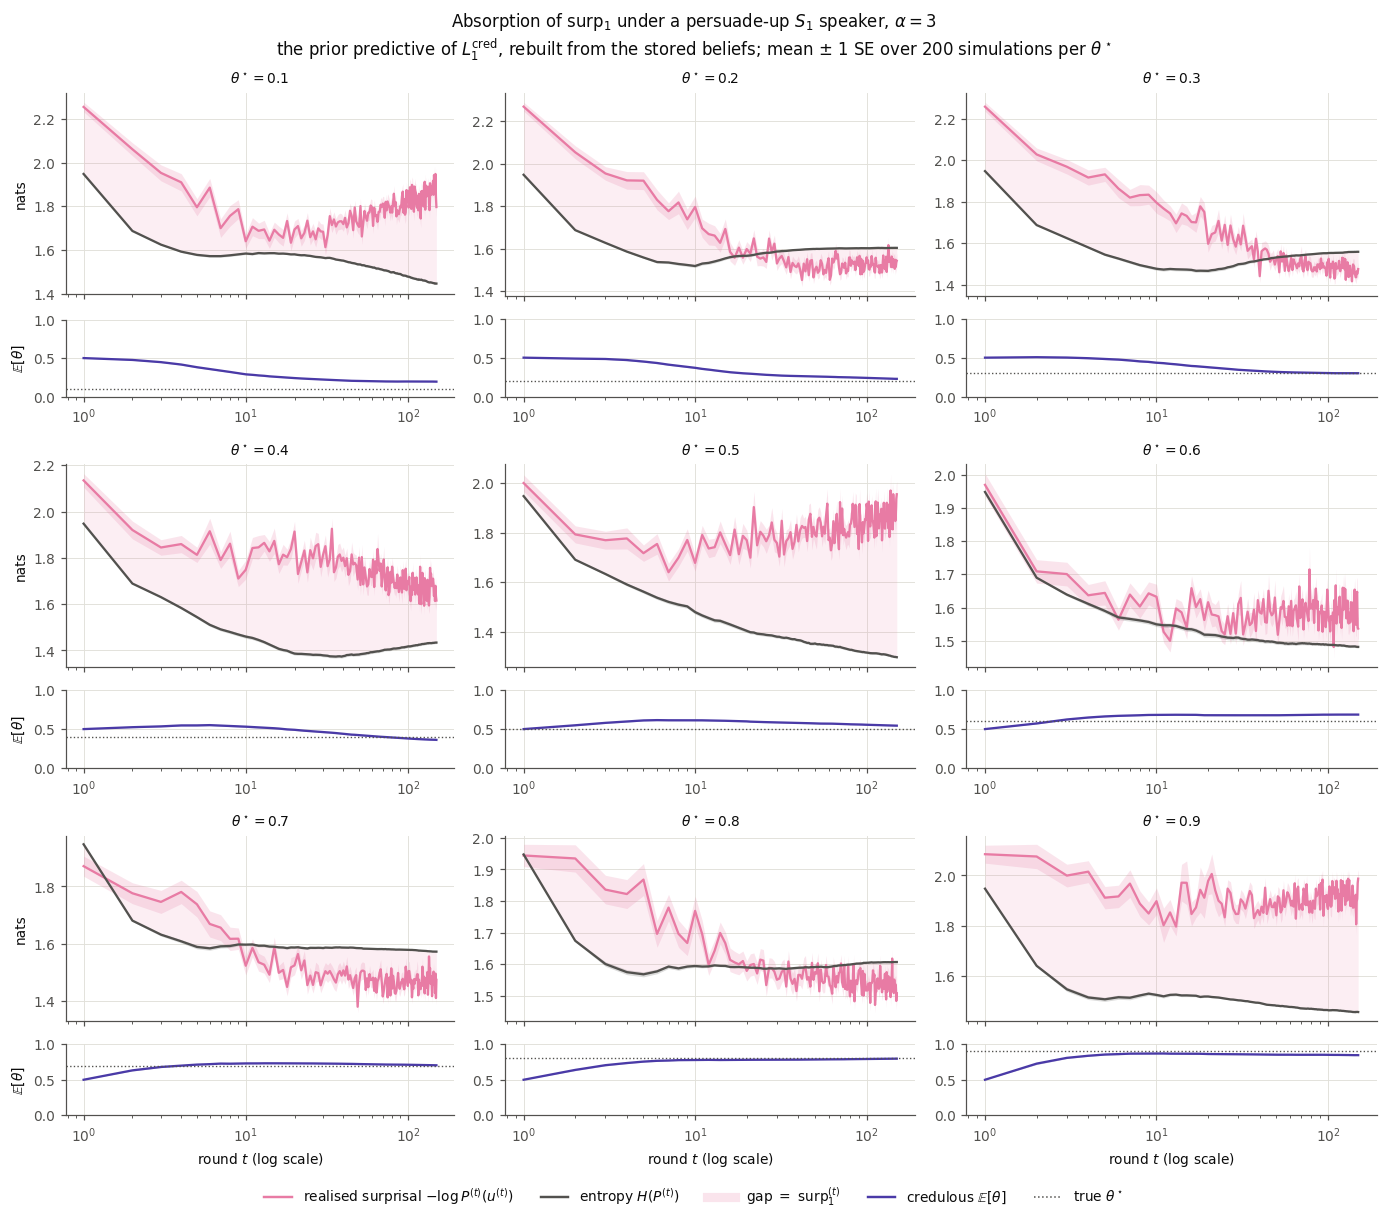

In [9]:
C_REAL, C_ENT, C_BEL = C_MAGENTA, INK2, C_VIOLET

fig = plt.figure(figsize=(12.5, 11), layout="constrained")
subs = fig.subfigures(3, 3, hspace=0.02, wspace=0.02)
for k, th in enumerate(thetas):
    r, c = divmod(k, 3)
    ax, axb = subs[r, c].subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1.15]})
    style(ax)
    style(axb)
    d = ABS.loc[th]
    t = d.index.to_numpy()
    for col, colour in [("realised", C_REAL), ("entropy", C_ENT)]:
        m, s = d[(col, "mean")].to_numpy(), d[(col, "sem")].to_numpy()
        ax.fill_between(t, m - s, m + s, color=colour, alpha=0.2, lw=0)
        ax.plot(t, m, color=colour, lw=1.5)
    ax.fill_between(t, d[("realised", "mean")], d[("entropy", "mean")], color=C_REAL, alpha=0.12, lw=0)
    ax.set_xscale("log")
    ax.set_title(rf"$\theta^\star = {th:g}$", fontsize=9)
    ax.tick_params(labelbottom=False)
    m, s = d[("E_theta", "mean")].to_numpy(), d[("E_theta", "sem")].to_numpy()
    axb.fill_between(t, m - s, m + s, color=C_BEL, alpha=0.25, lw=0)
    axb.plot(t, m, color=C_BEL, lw=1.5)
    axb.axhline(th, color=INK2, lw=0.9, ls=":")
    axb.set_xscale("log")
    axb.set_ylim(0, 1)
    axb.set_yticks([0, 0.5, 1])
    if c == 0:
        ax.set_ylabel("nats")
        axb.set_ylabel(r"$\mathbb{E}[\theta]$")
    if r == 2:
        axb.set_xlabel("round $t$ (log scale)")

handles = [Line2D([], [], color=C_REAL, lw=1.6, label=r"realised surprisal $-\log P^{(t)}(u^{(t)})$"),
           Line2D([], [], color=C_ENT, lw=1.6, label=r"entropy $H(P^{(t)})$"),
           Line2D([], [], color=C_REAL, lw=6, alpha=0.2, label=r"gap $=\ \mathrm{surp}_1^{(t)}$"),
           Line2D([], [], color=C_BEL, lw=1.6, label=r"credulous $\mathbb{E}[\theta]$"),
           Line2D([], [], color=INK2, lw=1.0, ls=":", label=r"true $\theta^\star$")]
fig.legend(handles=handles, loc="outside lower center", ncol=5, frameon=False)
fig.suptitle(r"Absorption of $\mathrm{surp}_1$ under a persuade-up $S_1$ speaker, $\alpha = 3$"
             "\n"
             r"the prior predictive of $L_1^{\mathrm{cred}}$, rebuilt from the stored beliefs;"
             r" mean $\pm$ 1 SE over 200 simulations per $\theta^\star$")
save_fig(fig, "S8_surp1_absorption.png")

## F3. Null calibration: variance ratio per $\theta^\star$

`S9_null_variance_ratio.png`. The variance across runs of $\mathrm{sus}^{(T)}$ divided by the analytic
$\bar\sigma^{2,(T)}/T$, against $T$, one panel per $\theta^\star$, both scores, informative speaker at
$\alpha = 3$. The null prediction is 1. The point is to see whether the ratio sits at 1 at every
$\theta^\star$ individually, or only after pooling. The table gives the ratio at $T = 150$.

saved results\report\figures\S9_null_variance_ratio.png


score,surp1,surp2
theta_star,,
0.1,0.955,0.998
0.2,0.808,1.016
0.3,0.973,1.089
0.4,0.920,1.118
0.5,1.063,0.927
0.6,0.954,0.996
0.7,0.958,0.904
0.8,0.918,1.026
0.9,1.011,1.134


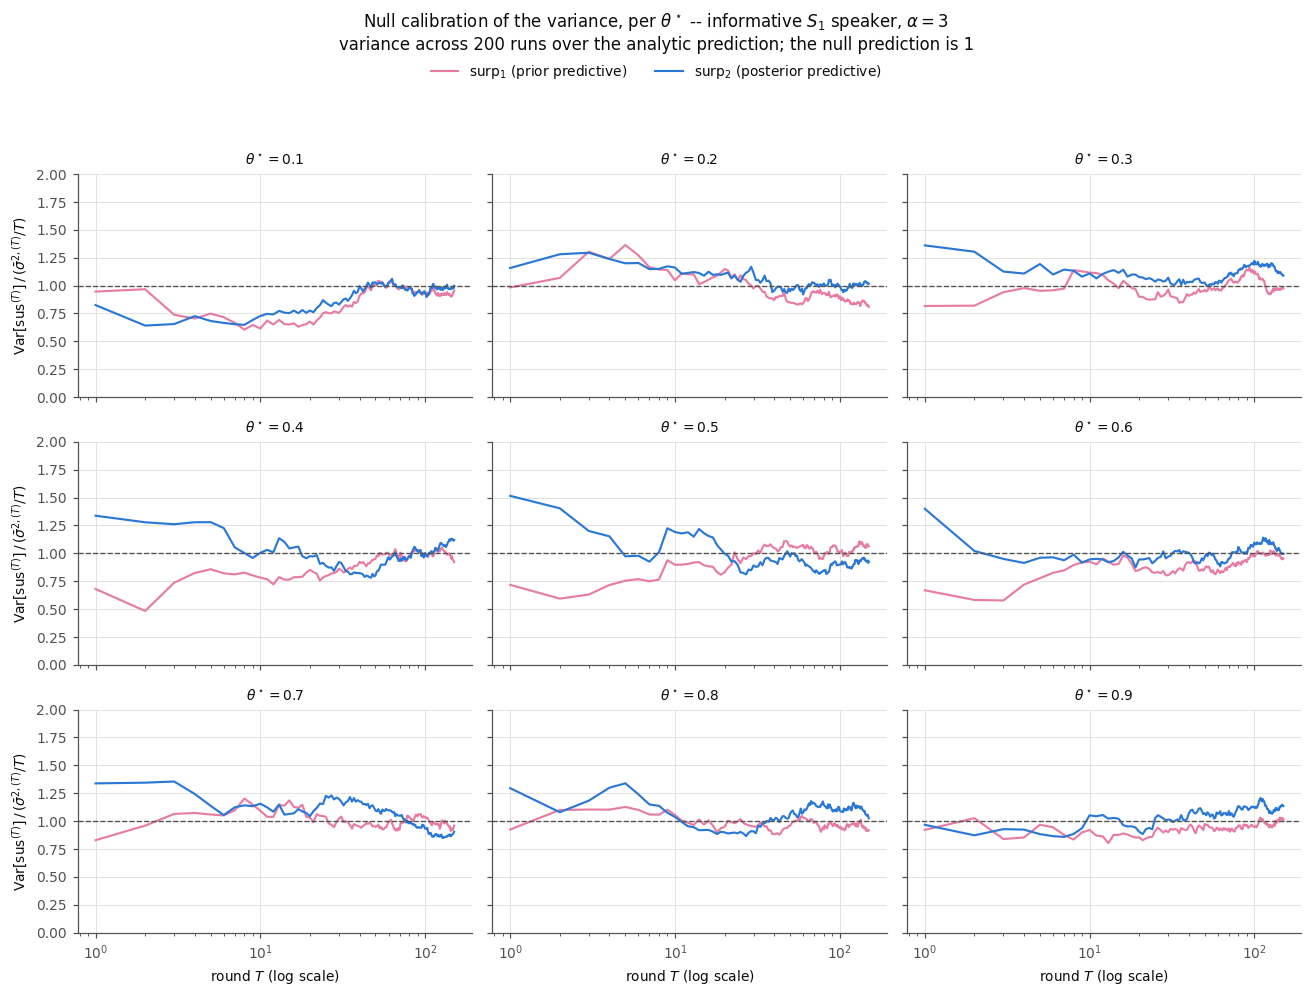

In [10]:
_g = runs_inf.groupby(["theta_star", "round"])
_vr = []
for _sc, _px in SC_PREFIX.items():
    _d = pd.DataFrame({"var": _g[f"{_px}_Sus"].var(ddof=1),
                       "sigma_bar2": _g[f"{_px}_sigma_bar2"].mean()}).reset_index()
    _d["ratio"] = _d["var"] / (_d["sigma_bar2"] / _d["round"])
    _d["score"] = _sc
    _vr.append(_d)
VAR_RATIO = pd.concat(_vr, ignore_index=True)

fig, axes = panel_grid(figsize=(12, 9))
for ax, th in zip(axes.flat, thetas):
    for sc in SC_PREFIX:
        d = VAR_RATIO[(VAR_RATIO["theta_star"] == th) & (VAR_RATIO["score"] == sc)]
        ax.plot(d["round"], d["ratio"], color=SC_COL[sc], lw=1.4, label=SC_LABEL[sc])
    ax.axhline(1, color=INK2, lw=0.9, ls="--")
    ax.set_xscale("log")
    ax.set_ylim(0, 2)
finish_panels(fig, axes, thetas, "round $T$ (log scale)",
              r"$\mathrm{Var}[\mathrm{sus}^{(T)}] \,/\, (\bar\sigma^{2,(T)}/T)$",
              title=r"Null calibration of the variance, per $\theta^\star$"
                    r" -- informative $S_1$ speaker, $\alpha = 3$",
              subtitle="variance across 200 runs over the analytic prediction; the null prediction is 1",
              ncol=2)
save_fig(fig, "S9_null_variance_ratio.png")

VAR_RATIO[VAR_RATIO["round"] == ROUNDS].pivot(index="theta_star", columns="score",
                                              values="ratio").round(3)

## F4. Detection time

`S10_tau_violins.png`. Distribution of the crossing round $\tau$ over *detected* runs at $c = 3.5$, one
violin per score side by side, log $y$. Left: against $\alpha$, pooled over $\theta^\star$ and over both
persuasive goals. Right: against $\theta^\star$ at $\alpha = 3$, pooled over both persuasive goals. The
power (fraction of runs detected by round 150) is printed under each violin, because a violin over
detected runs alone hides the misses.

saved results\report\figures\S10_tau_violins.png


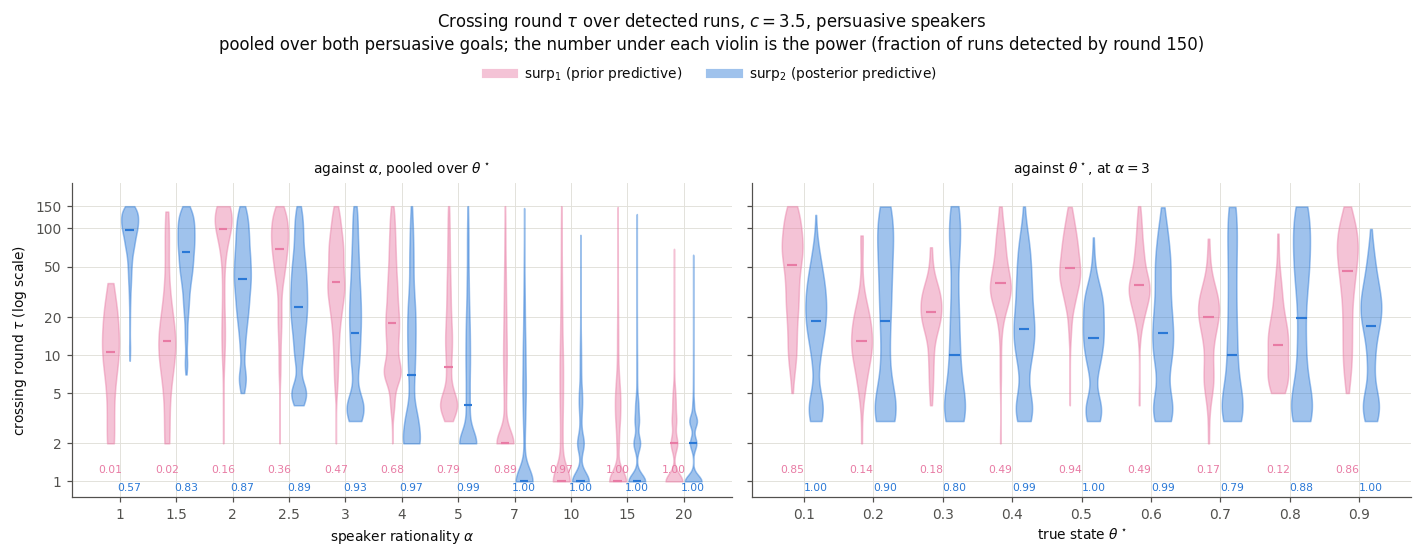

In [11]:
def _violin_panel(ax, groups, tau, mask_base, xlabel):
    # groups: list of (label, boolean mask over RUNS rows)
    ticks = []
    for i, (lab, m) in enumerate(groups):
        ticks.append(i)
        for j, sc in enumerate(SC_PREFIX):
            sel = m & mask_base
            det = sel & (tau[sc] > 0)
            pos = i + (j - 0.5) * 0.34
            vals = np.log10(tau[sc][det].astype(float))
            if vals.size >= 2:
                parts = ax.violinplot([vals], positions=[pos], widths=0.3,
                                      showextrema=False, showmedians=True)
                for b in parts["bodies"]:
                    b.set_facecolor(SC_COL[sc])
                    b.set_edgecolor(SC_COL[sc])
                    b.set_alpha(0.45)
                parts["cmedians"].set_color(SC_COL[sc])
                parts["cmedians"].set_linewidth(1.4)
            power = det.sum() / max(sel.sum(), 1)
            ax.annotate(f"{power:.2f}", xy=(pos, 0.015 + 0.055 * (1 - j)),
                        xycoords=("data", "axes fraction"), ha="center", va="bottom",
                        fontsize=7, color=SC_COL[sc])
    ax.set_xticks(ticks)
    ax.set_xticklabels([lab for lab, _ in groups])
    ax.set_xlabel(xlabel)
    yt = np.array([1, 2, 5, 10, 20, 50, 100, 150])
    ax.set_yticks(np.log10(yt))
    ax.set_yticklabels(yt)
    ax.set_ylim(np.log10(0.75), np.log10(230))
    style(ax)


TAU_REF = {sc: tau_stored(sc, C_REF) for sc in SC_PREFIX}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
_violin_panel(axes[0], [(f"{a:g}", (RUNS["alpha"] == a).to_numpy()) for a in ALPHAS],
              TAU_REF, IS_PERS, r"speaker rationality $\alpha$")
_violin_panel(axes[1], [(f"{t:g}", (RUNS["theta_star"] == t).to_numpy()) for t in thetas],
              TAU_REF, IS_PERS & (RUNS["alpha"] == ALPHA).to_numpy(), r"true state $\theta^\star$")
axes[0].set_ylabel(r"crossing round $\tau$ (log scale)")
axes[0].set_title(r"against $\alpha$, pooled over $\theta^\star$", fontsize=9)
axes[1].set_title(r"against $\theta^\star$, at $\alpha = 3$", fontsize=9)
handles = [Line2D([], [], color=SC_COL[sc], lw=6, alpha=0.45, label=SC_LABEL[sc]) for sc in SC_PREFIX]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.925), ncol=2, frameon=False)
fig.suptitle(rf"Crossing round $\tau$ over detected runs, $c = {C_REF:g}$, persuasive speakers"
             "\n"
             "pooled over both persuasive goals; the number under each violin is the power"
             " (fraction of runs detected by round 150)", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.86))
save_fig(fig, "S10_tau_violins.png")

## F5. Crossing time: early or never

`S11_tau_histogram.png`. Histogram of $\tau$ over log-spaced bins from 1 to 150 plus a final "never" bar,
for the persuasive runs at $\alpha = 3$, $c = 3.5$, one panel per score. This is the direct evidence for
"$\mathrm{surp}_1$ detects, if at all, from the early rounds only": its mass should sit in the first few
rounds beside a large "never" bar, while $\mathrm{surp}_2$ spreads out with a small "never" bar.

Bars are fractions *per bin*, and the bins widen towards the right (the label gives the rounds each bin
covers), so heights are not per-round rates.

saved results\report\figures\S11_tau_histogram.png


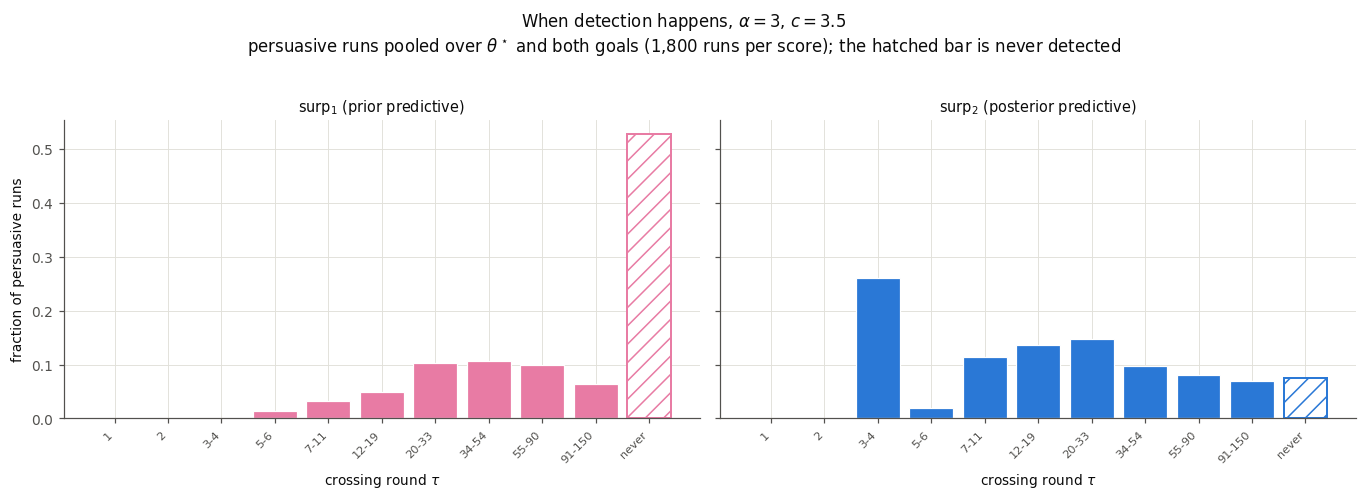

In [12]:
EDGES = np.unique(np.round(np.logspace(0, np.log10(ROUNDS + 1), 11)).astype(int))
EDGES[-1] = ROUNDS + 1
_labels = [(f"{lo}" if hi - lo == 1 else f"{lo}-{hi - 1}") for lo, hi in zip(EDGES[:-1], EDGES[1:])]
_labels.append("never")

_mask = IS_PERS & (RUNS["alpha"] == ALPHA).to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, sc in zip(axes, SC_PREFIX):
    tau = TAU_REF[sc][_mask]
    counts, _ = np.histogram(tau[tau > 0], bins=EDGES)
    frac = np.append(counts, (tau < 0).sum()) / tau.size
    x = np.arange(len(frac))
    ax.bar(x[:-1], frac[:-1], width=0.82, color=SC_COL[sc], edgecolor="white", lw=0.8)
    ax.bar(x[-1], frac[-1], width=0.82, color="white", edgecolor=SC_COL[sc], lw=1.3, hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(_labels, rotation=45, ha="right", fontsize=7.5)
    ax.set_title(SC_LABEL[sc], fontsize=9.5)
    ax.set_xlabel(r"crossing round $\tau$")
    style(ax)
axes[0].set_ylabel("fraction of persuasive runs")
fig.suptitle(rf"When detection happens, $\alpha = 3$, $c = {C_REF:g}$"
             "\n"
             r"persuasive runs pooled over $\theta^\star$ and both goals"
             " (1,800 runs per score); the hatched bar is never detected", y=1.02)
fig.tight_layout()
save_fig(fig, "S11_tau_histogram.png")

## F6. Separation per cell

`S12_dprime_heatmap.png`. Heatmap of
$d' = (\mathbb{E}[\mathrm{sus}^{(150)} \mid \text{persuasive}] - \mathbb{E}[\mathrm{sus}^{(150)} \mid
\mathrm{inf}]) / \mathrm{sd}(\mathrm{sus}^{(150)} \mid \mathrm{inf})$ on the
$\theta^\star \times \alpha$ grid, one panel per score, shared colour scale, persuasive being the mean of
the two goals. The report quotes only the median over cells; this shows where the difference lives.

Both panels share one colour scale. It is logarithmic because $d'$ spans three orders of magnitude, and
cells with $d' \leq 0$ (no separation at all) fall outside a log scale, so they are drawn in orange.

saved results\report\figures\S12_dprime_heatmap.png


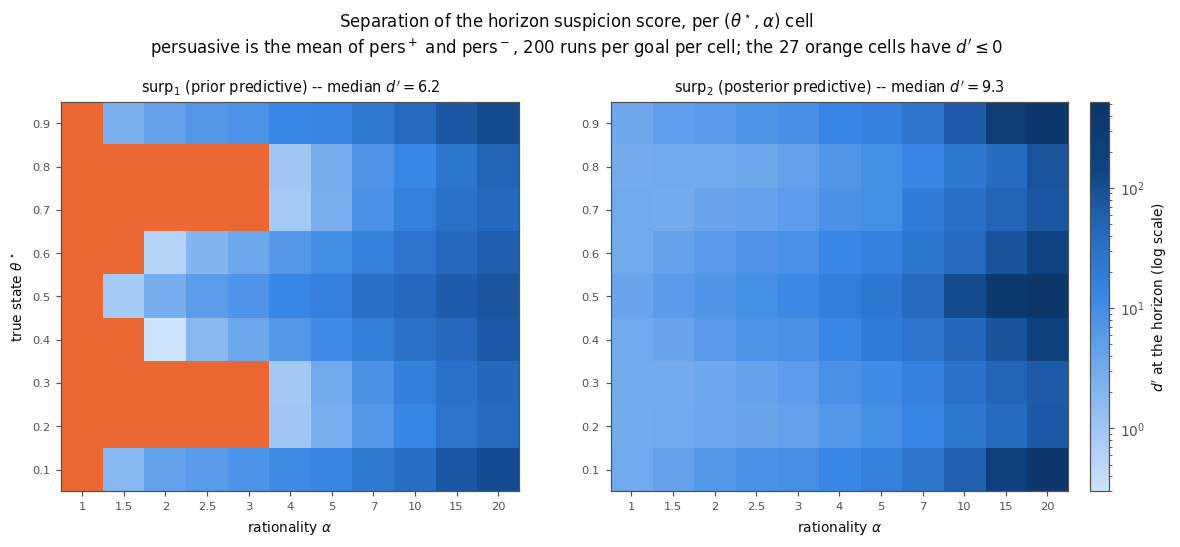

In [13]:
_rows = []
for _sc, _px in SC_PREFIX.items():
    _g = RUNS.groupby(["theta_star", "alpha", "psi_star"])[f"Sus150_{_px}"].agg(["mean", "std"])
    _g = _g.reset_index()
    _inf = _g[_g["psi_star"] == "inf"].set_index(["theta_star", "alpha"])
    _per = _g[_g["psi_star"] != "inf"].groupby(["theta_star", "alpha"])["mean"].mean()
    _d = ((_per - _inf["mean"]) / _inf["std"]).rename("dprime").reset_index()
    _d["score"] = _sc
    _rows.append(_d)
DPRIME = pd.concat(_rows, ignore_index=True)

_cmap = seq_blue.copy()
_cmap.set_bad(ORANGES[3])          # cells with no separation at all (d' <= 0)
_norm = LogNorm(vmin=0.3, vmax=DPRIME["dprime"].max())
_n_bad = int((DPRIME["dprime"] <= 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, sc in zip(axes, SC_PREFIX):
    M = (DPRIME[DPRIME["score"] == sc]
         .pivot(index="theta_star", columns="alpha", values="dprime"))
    im = ax.imshow(np.ma.masked_less_equal(M.to_numpy(), 0.0), origin="lower", aspect="auto",
                   cmap=_cmap, norm=_norm)
    ax.set_xticks(range(len(M.columns)), [f"{a:g}" for a in M.columns], fontsize=7.5)
    ax.set_yticks(range(len(M.index)), [f"{t:g}" for t in M.index], fontsize=7.5)
    ax.set_xlabel(r"rationality $\alpha$")
    ax.set_title(rf"{SC_LABEL[sc]} -- median $d' = {np.median(M.to_numpy()):.1f}$", fontsize=9.5)
    ax.grid(False)
axes[0].set_ylabel(r"true state $\theta^\star$")
cb = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.02)
cb.set_label(r"$d'$ at the horizon (log scale)")
fig.suptitle(r"Separation of the horizon suspicion score, per $(\theta^\star, \alpha)$ cell"
             "\n"
             r"persuasive is the mean of $\mathrm{pers}^+$ and $\mathrm{pers}^-$, 200 runs per goal"
             rf" per cell; the {_n_bad} orange cells have $d' \leq 0$", y=1.06)
save_fig(fig, "S12_dprime_heatmap.png")

## F7. False alarm against the horizon

`S13_false_alarm_vs_T.png`. Top row: the fraction of informative runs that have crossed by round $T$,
against $T$ (log $x$), one line per $c$, one panel per score, pooled over $\theta^\star$ and
$\alpha \ge 1.5$. The dotted line at each $c$ is the fixed-sample-size nominal level $\Phi(-c)$. The
boundary is inspected every round, so the crossing rate grows with the horizon and sits above the nominal
level. Bottom row: the same at $c = 3.5$ only, resolved by $\theta^\star$, which is where the
$\mathrm{surp}_1$ inflation from the early positive bias at extreme $\theta^\star$ shows up.

saved results\report\figures\S13_false_alarm_vs_T.png


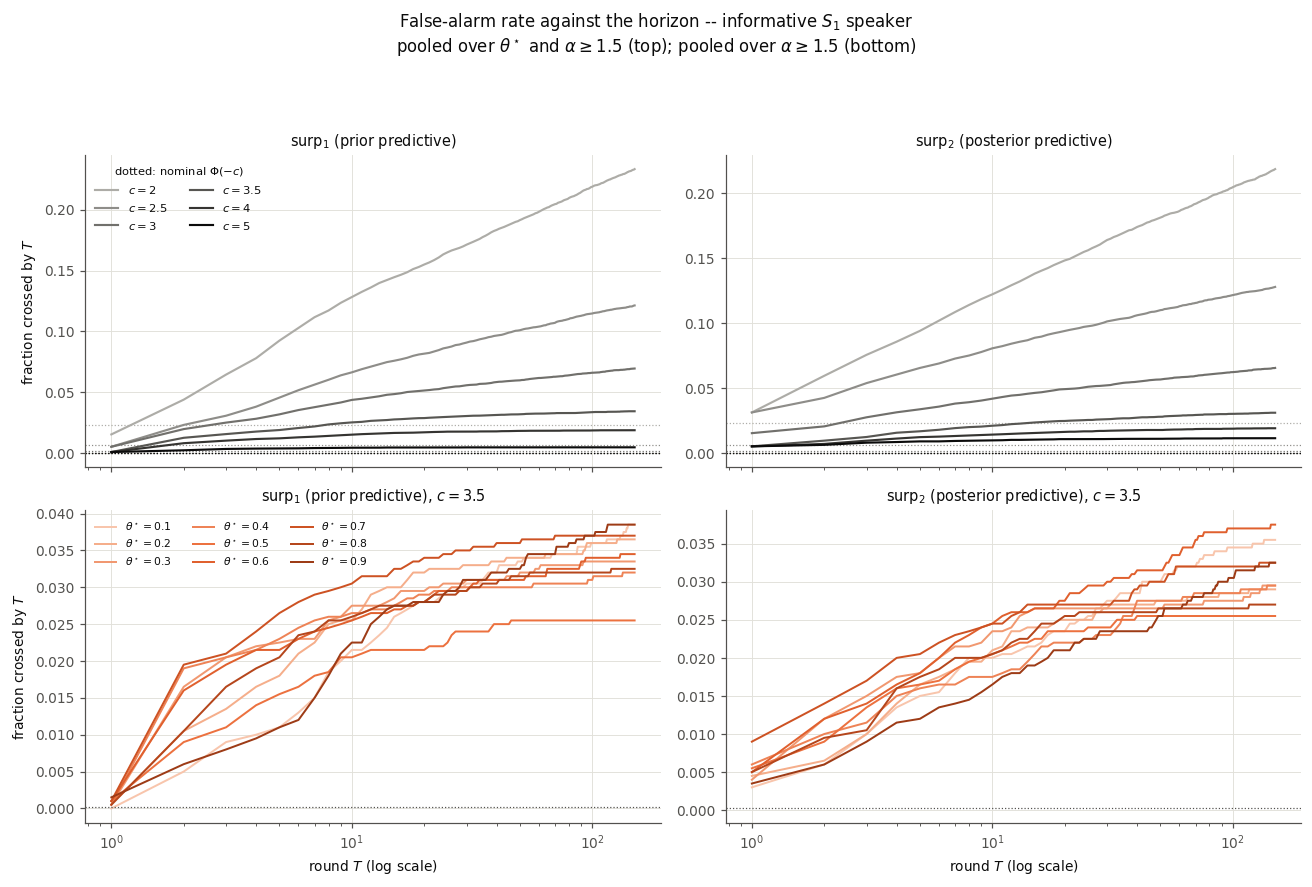

In [14]:
_mask_fa = IS_INF & POOLED
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, sc in enumerate(SC_PREFIX):
    ax = axes[0, j]
    for k, c in enumerate(C_LIST):
        col = seq_param(0.15 + 0.85 * k / (len(C_LIST) - 1))
        ax.plot(ROUND_AXIS, crossed_by_T(sc, c)[_mask_fa].mean(0), color=col, lw=1.4,
                label=f"$c = {c:g}$")
        ax.axhline(0.5 * math.erfc(c / math.sqrt(2)), color=col, lw=0.8, ls=":")
    ax.set_xscale("log")
    ax.set_title(SC_LABEL[sc], fontsize=9.5)
    style(ax)

    ax = axes[1, j]
    for k, th in enumerate(thetas):
        m = _mask_fa & (RUNS["theta_star"] == th).to_numpy()
        ax.plot(ROUND_AXIS, crossed_by_T(sc, C_REF)[m].mean(0),
                color=seq_theta(0.1 + 0.9 * k / (len(thetas) - 1)), lw=1.3,
                label=rf"$\theta^\star = {th:g}$")
    ax.axhline(0.5 * math.erfc(C_REF / math.sqrt(2)), color=INK2, lw=0.8, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel("round $T$ (log scale)")
    ax.set_title(rf"{SC_LABEL[sc]}, $c = {C_REF:g}$", fontsize=9.5)
    style(ax)
axes[0, 0].set_ylabel("fraction crossed by $T$")
axes[1, 0].set_ylabel("fraction crossed by $T$")
axes[0, 0].legend(frameon=False, fontsize=7.5, ncol=2, loc="upper left",
                  title="dotted: nominal $\\Phi(-c)$", title_fontsize=7.5)
axes[1, 0].legend(frameon=False, fontsize=7, ncol=3, loc="upper left")
fig.suptitle(r"False-alarm rate against the horizon -- informative $S_1$ speaker"
             "\n"
             r"pooled over $\theta^\star$ and $\alpha \geq 1.5$ (top);"
             r" pooled over $\alpha \geq 1.5$ (bottom)", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "S13_false_alarm_vs_T.png")

## F8. Persuade-up / persuade-down symmetry

`S14_goal_symmetry.png`. The symmetry claim is that persuading up at $\theta^\star$ is the mirror of
persuading down at $1 - \theta^\star$, so both comparisons here are mirrored.

Top: per-cell power against $\mathrm{pers}^+$ at $(\theta^\star, \alpha)$ versus against
$\mathrm{pers}^-$ at $(1 - \theta^\star, \alpha)$, at $c = 3.5$, both scores, with the diagonal. Bottom:
the per-$\theta^\star$ running mean for $\mathrm{surp}_2$ at $\alpha = 3$, $\mathrm{pers}^+$ at
$\theta^\star$ overlaid on $\mathrm{pers}^-$ at $1 - \theta^\star$; under exact symmetry the two curves
coincide.

saved results\report\figures\S14_goal_symmetry.png
max |power difference| between mirrored cells: {'surp1': 0.095, 'surp2': 0.115}


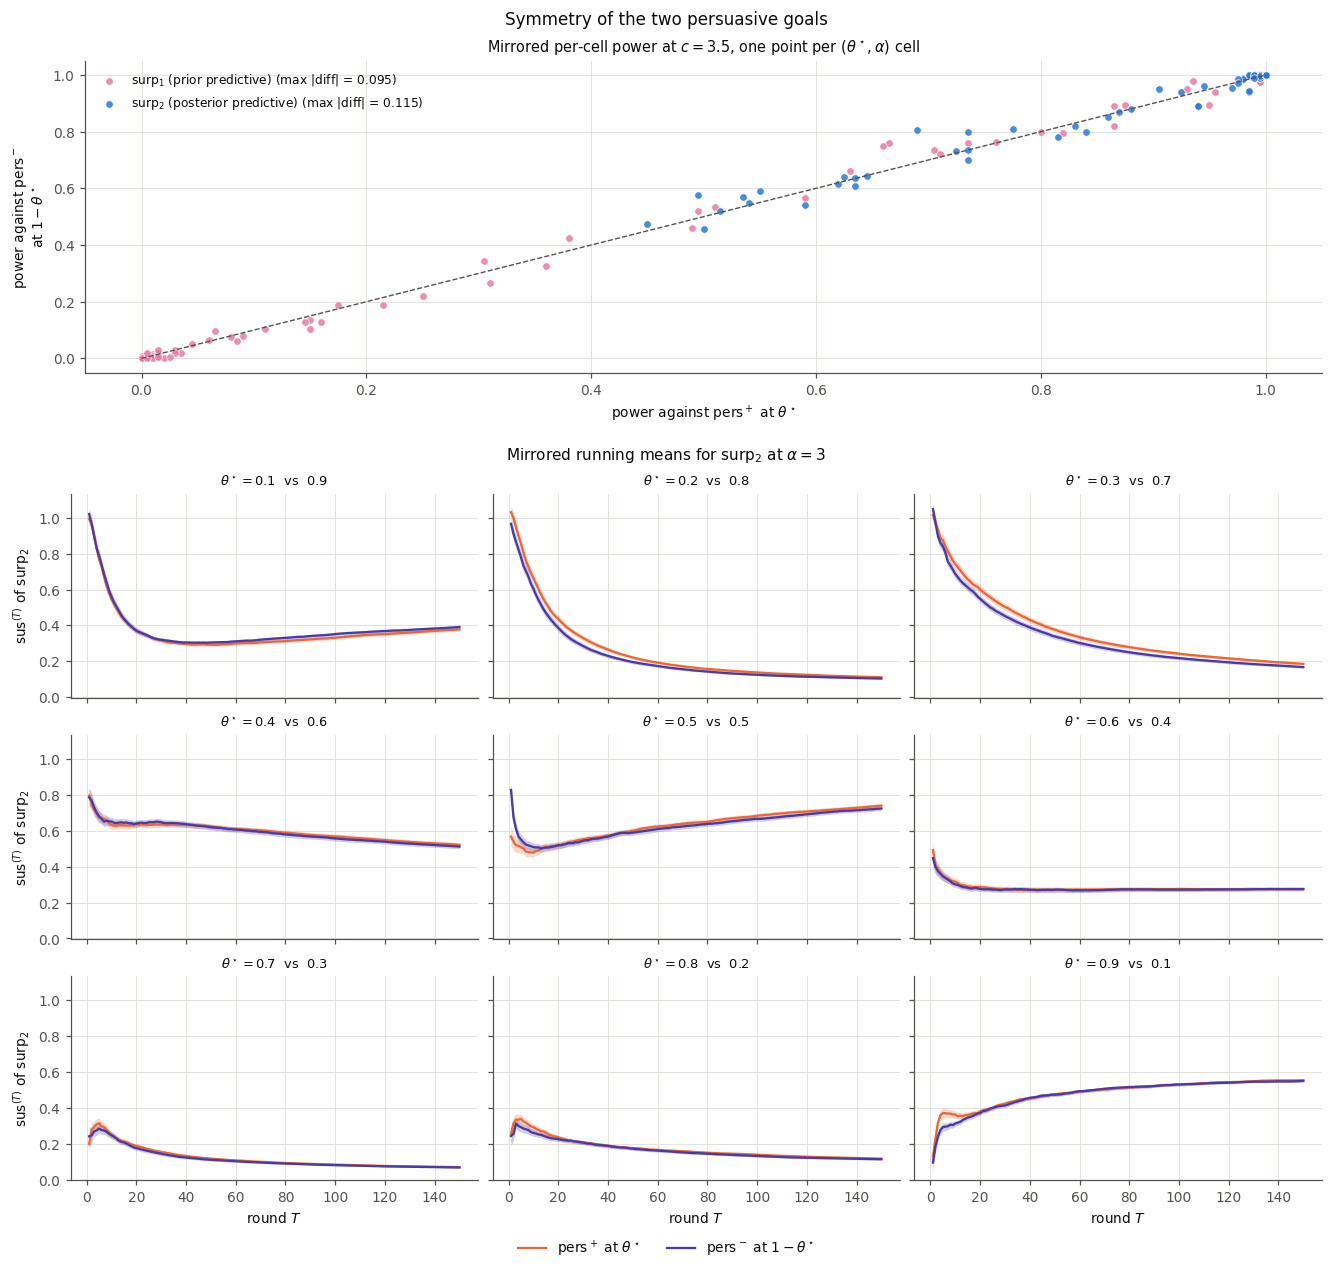

In [15]:
stats_pm = summarise_sus(runs_pm)

_det = pd.DataFrame({f"det_{sc}": (TAU_REF[sc] > 0) for sc in SC_PREFIX})
_pw = (pd.concat([RUNS[["theta_star", "alpha", "psi_star"]], _det], axis=1)
       .groupby(["theta_star", "alpha", "psi_star"]).mean().reset_index())
POWER_CELL = _pw[_pw["psi_star"] != "inf"].pivot(index=["theta_star", "alpha"],
                                                 columns="psi_star",
                                                 values=[f"det_{sc}" for sc in SC_PREFIX])

_mirror = [(th, round(1 - th, 10)) for th in thetas]
fig = plt.figure(figsize=(12, 11.5), layout="constrained")
sub = fig.subfigures(2, 1, height_ratios=[1.0, 2.1])

ax = style(sub[0].subplots(1, 1))
_maxdiff = {}
for sc in SC_PREFIX:
    up = POWER_CELL[(f"det_{sc}", "high")]
    dn = POWER_CELL[(f"det_{sc}", "low")]
    x, y = [], []
    for th, th_m in _mirror:
        for a in ALPHAS:
            x.append(up.loc[(th, a)])
            y.append(dn.loc[(th_m, a)])
    x, y = np.array(x), np.array(y)
    _maxdiff[sc] = float(np.abs(x - y).max())
    ax.scatter(x, y, s=24, facecolor=SC_COL[sc], edgecolor="white", lw=0.5, alpha=0.85,
               label=f"{SC_LABEL[sc]} (max |diff| = {_maxdiff[sc]:.3f})")
ax.plot([0, 1], [0, 1], color=INK2, lw=0.9, ls="--")
ax.set_xlabel(r"power against $\mathrm{pers}^+$ at $\theta^\star$")
ax.set_ylabel(r"power against $\mathrm{pers}^-$" "\n" r"at $1 - \theta^\star$")
ax.set_title(rf"Mirrored per-cell power at $c = {C_REF:g}$,"
             r" one point per $(\theta^\star, \alpha)$ cell", fontsize=9.5)
ax.legend(frameon=False, fontsize=8, loc="upper left")

axes = sub[1].subplots(3, 3, sharex=True, sharey=True)
for ax, (th, th_m) in zip(axes.flat, _mirror):
    style(ax)
    for d, col, lab in [(stats_pp["surp2"].loc[th], C_ORANGE, r"$\mathrm{pers}^+$ at $\theta^\star$"),
                        (stats_pm["surp2"].loc[th_m], C_VIOLET,
                         r"$\mathrm{pers}^-$ at $1 - \theta^\star$")]:
        ax.fill_between(d.index, d["sus_mean"] - d["sus_se"], d["sus_mean"] + d["sus_se"],
                        color=col, alpha=0.25, lw=0)
        ax.plot(d.index, d["sus_mean"], color=col, lw=1.5, label=lab)
    ax.set_title(rf"$\theta^\star = {th:g}$  vs  ${th_m:g}$", fontsize=8.5)
for ax in axes[-1]:
    ax.set_xlabel("round $T$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\mathrm{sus}^{(T)}$ of $\mathrm{surp}_2$")
h, l = axes[0, 0].get_legend_handles_labels()
sub[1].legend(h, l, loc="outside lower center", ncol=2, frameon=False)
sub[1].suptitle(r"Mirrored running means for $\mathrm{surp}_2$ at $\alpha = 3$", fontsize=10)
fig.suptitle("Symmetry of the two persuasive goals", fontsize=11)
save_fig(fig, "S14_goal_symmetry.png")
print("max |power difference| between mirrored cells:", {k: round(v, 4) for k, v in _maxdiff.items()})

## F9. Horizon distribution per $\theta^\star$

`S15_separation_per_theta.png`. The pooled density of $\mathrm{sus}^{(150)}$ resolved by $\theta^\star$,
at $\alpha = 3$, three goals, one block per score. This shows whether the bimodality of $\mathrm{surp}_1$
in the pooled figure is a mixture across $\theta^\star$ (some cells detected, some not) rather than
something happening within a cell.

saved results\report\figures\S15_separation_per_theta.png


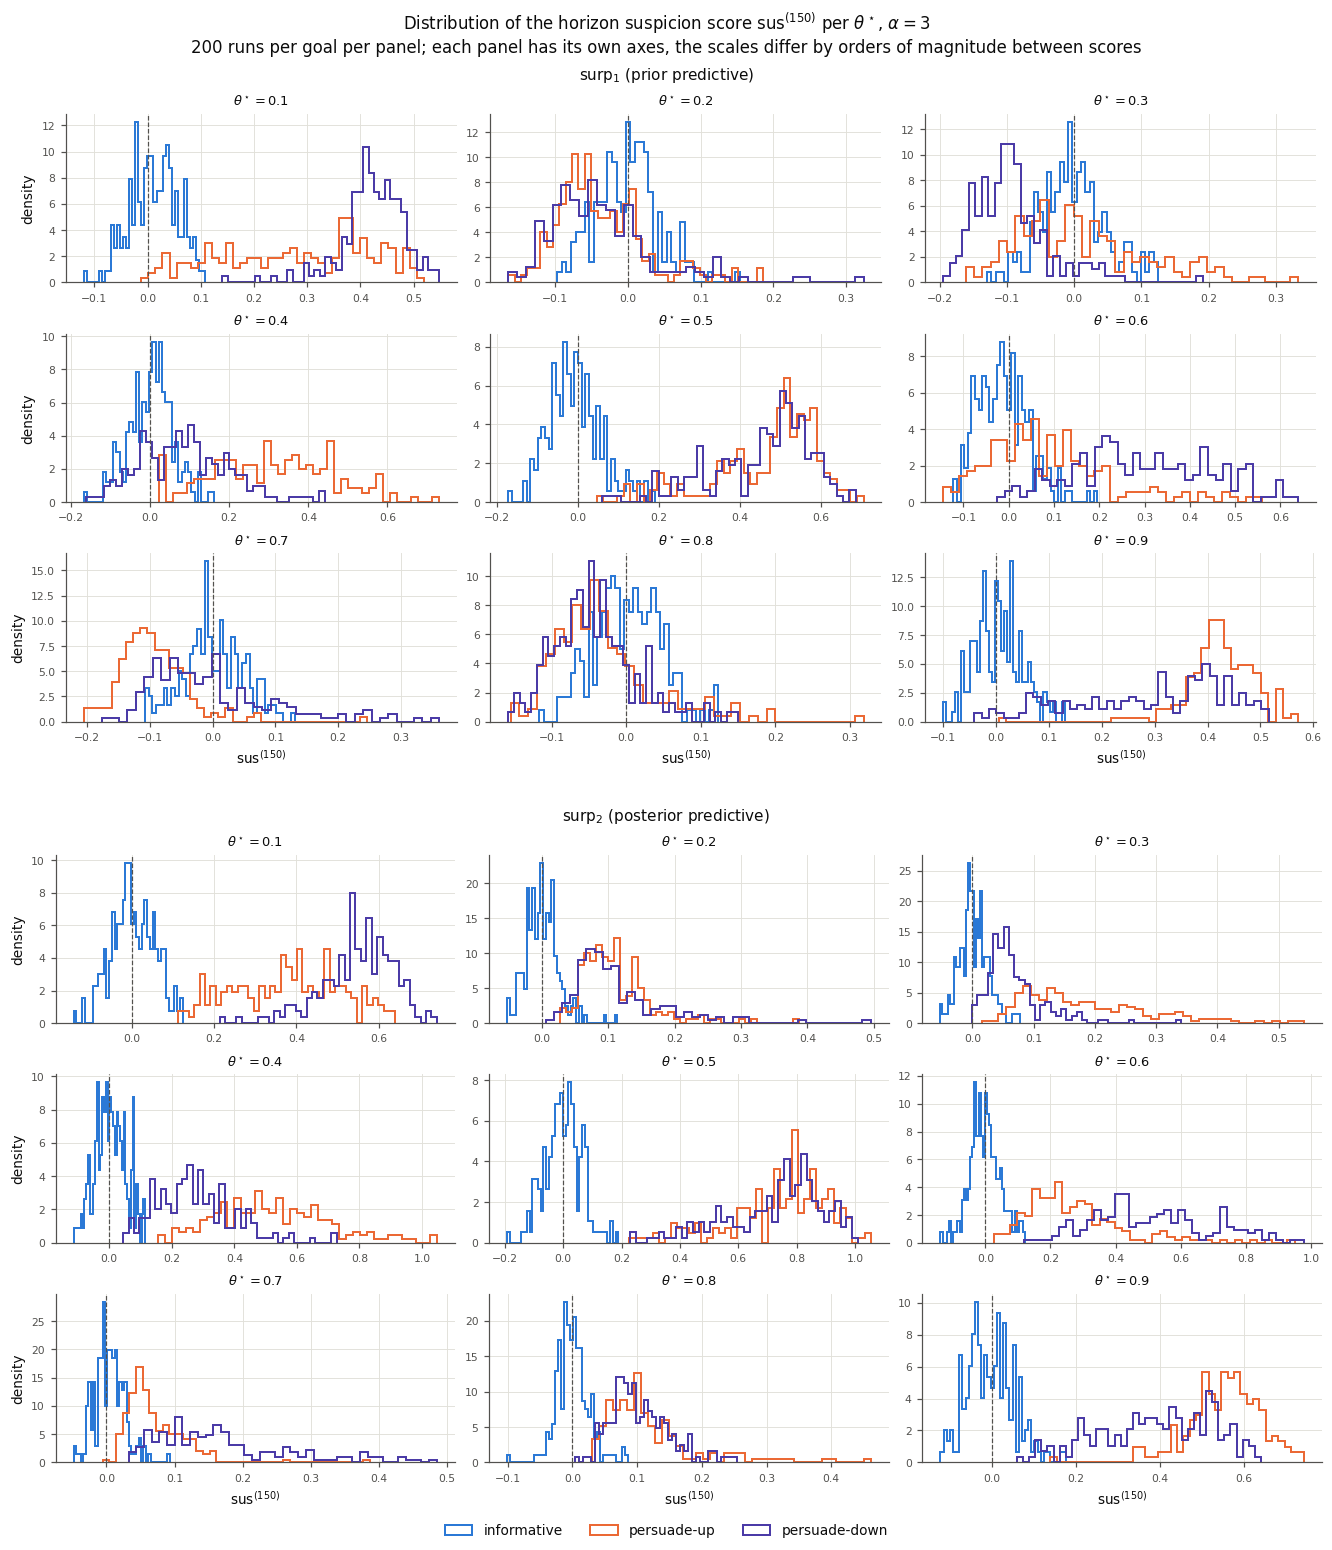

In [16]:
_sel = RUNS[RUNS["alpha"] == ALPHA]
fig = plt.figure(figsize=(12, 14), layout="constrained")
sub = fig.subfigures(2, 1, hspace=0.04)
for s, sc in zip(sub, SC_PREFIX):
    axes = s.subplots(3, 3, sharex=False, sharey=False)
    for ax, th in zip(axes.flat, thetas):
        style(ax)
        for psi_agg, psi_raw in PSI_AGG2RAW.items():
            x = _sel[(_sel["theta_star"] == th) & (_sel["psi_star"] == psi_agg)][f"Sus150_{SC_PREFIX[sc]}"]
            ax.hist(x, bins=40, histtype="step", density=True, lw=1.3,
                    color=PSI_COL[psi_raw], label=PSI_LABEL[psi_raw])
        ax.axvline(0, color=INK2, lw=0.8, ls="--")
        ax.set_title(rf"$\theta^\star = {th:g}$", fontsize=8.5)
        ax.tick_params(labelsize=7)
    for ax in axes[-1]:
        ax.set_xlabel(rf"$\mathrm{{sus}}^{{(150)}}$")
    for ax in axes[:, 0]:
        ax.set_ylabel("density")
    _h, _l = axes[0, 0].get_legend_handles_labels()
    s.suptitle(SC_LABEL[sc], fontsize=10)
fig.legend(_h, _l, loc="outside lower center", ncol=3, frameon=False)
fig.suptitle(r"Distribution of the horizon suspicion score $\mathrm{sus}^{(150)}$ per $\theta^\star$,"
             r" $\alpha = 3$" "\n" "200 runs per goal per panel; each panel has its own axes, the"
             " scales differ by orders of magnitude between scores")
save_fig(fig, "S15_separation_per_theta.png")

## F10. Power against $\alpha$, per $\theta^\star$

`S16_power_vs_alpha_per_theta.png`. Power at $c = 3.5$ against $\alpha$ (log $x$), one line per
$\theta^\star$, one panel per score, pooled over the two persuasive goals. The same information as the
rate surface of the existing figure, but readable as curves.

saved results\report\figures\S16_power_vs_alpha_per_theta.png


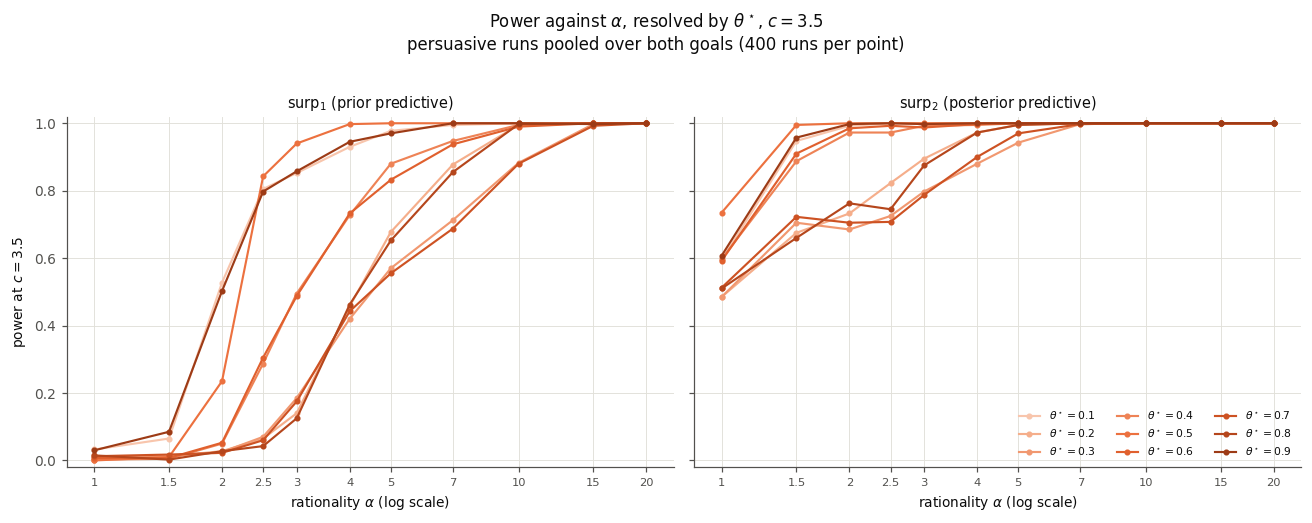

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, sc in zip(axes, SC_PREFIX):
    for k, th in enumerate(thetas):
        p = [(TAU_REF[sc][IS_PERS & (RUNS["theta_star"] == th).to_numpy()
                          & (RUNS["alpha"] == a).to_numpy()] > 0).mean() for a in ALPHAS]
        ax.plot(ALPHAS, p, color=seq_theta(0.1 + 0.9 * k / (len(thetas) - 1)), lw=1.4,
                marker="o", ms=3, label=rf"$\theta^\star = {th:g}$")
    ax.set_xscale("log")
    ax.set_xticks(ALPHAS, [f"{a:g}" for a in ALPHAS], fontsize=7.5)
    ax.minorticks_off()
    ax.set_xlabel(r"rationality $\alpha$ (log scale)")
    ax.set_title(SC_LABEL[sc], fontsize=9.5)
    ax.set_ylim(-0.02, 1.02)
    style(ax)
axes[0].set_ylabel(rf"power at $c = {C_REF:g}$")
axes[1].legend(frameon=False, fontsize=7, ncol=3, loc="lower right")
fig.suptitle(rf"Power against $\alpha$, resolved by $\theta^\star$, $c = {C_REF:g}$"
             "\n" "persuasive runs pooled over both goals (400 runs per point)", y=1.02)
fig.tight_layout()
save_fig(fig, "S16_power_vs_alpha_per_theta.png")

## Tables

Written to `results/report/tables/`.

- **T1** `operating_characteristics.csv` -- the report's operating-characteristics table recomputed, with
  the quartiles of $\tau$ and the fraction of detected runs that cross by round 10 added. Rates are
  pooled over $\theta^\star$ and $\alpha \ge 1.5$.
- **T2** `per_theta_c35.csv` -- at $c = 3.5$, $\alpha = 3$: per $\theta^\star$ and score, the false-alarm
  rate, the power (mean of the two goals), the median $\tau$, and the long-run level of the suspicion
  score under the persuasive speakers. The table version of the two per-$\theta^\star$ running-mean
  figures.
- **T3** `null_bias.csv` -- at $\alpha = 3$, per $\theta^\star$ and score: the mean per-round score under
  the informative speaker at $t = 1, 5, 20, 150$ (the finite-$T$ bias and its decay) and the mean
  $\mathrm{sus}^{(150)}$.

In [18]:
_rows = []
for sc in SC_PREFIX:
    for c in C_LIST:
        tau = tau_stored(sc, c)
        det = tau > 0
        fa = det[IS_INF & POOLED].mean()
        row = {"score": sc, "c": c, "false_alarm": fa}
        for psi_agg, key in [("high", "power_pers_up"), ("low", "power_pers_down")]:
            row[key] = det[(RUNS["psi_star"] == psi_agg).to_numpy() & POOLED].mean()
        d = tau[IS_PERS & POOLED & det]
        row["median_tau"] = float(np.median(d))
        row["p25_tau"] = float(np.percentile(d, 25))
        row["p75_tau"] = float(np.percentile(d, 75))
        row["frac_detected_by_10"] = float((d <= 10).mean())
        _rows.append(row)
T1 = pd.DataFrame(_rows).round(4)
save_table(T1, "operating_characteristics.csv")
T1

saved results\report\tables\operating_characteristics.csv


,score,c,false_alarm,power_pers_up,power_pers_down,median_tau,p25_tau,p75_tau,frac_detected_by_10
0,surp1,2.0,0.2335,0.7431,0.7398,3.0,1.0,11.0,0.7487
1,surp1,2.5,0.1213,0.6992,0.7004,4.0,1.0,14.0,0.7093
2,surp1,3.0,0.0694,0.6666,0.6689,4.0,1.0,17.0,0.6749
3,surp1,3.5,0.0343,0.6351,0.6358,5.0,2.0,21.0,0.6425
4,surp1,4.0,0.0187,0.6061,0.6079,5.0,1.0,23.0,0.6213
5,surp1,5.0,0.0046,0.5564,0.5592,6.0,1.0,28.0,0.5841
6,surp2,2.0,0.2186,0.9958,0.9948,2.0,1.0,7.0,0.7986
7,surp2,2.5,0.1278,0.9886,0.9876,3.0,1.0,12.0,0.7273
8,surp2,3.0,0.0654,0.9739,0.9704,4.0,1.0,20.0,0.6567
9,surp2,3.5,0.0309,0.9469,0.9466,5.0,2.0,27.0,0.6063


In [19]:
_rows = []
_a = (RUNS["alpha"] == ALPHA).to_numpy()
for sc, px in SC_PREFIX.items():
    tau = tau_stored(sc, C_REF)
    det = tau > 0
    for th in thetas:
        m = _a & (RUNS["theta_star"] == th).to_numpy()
        pers = m & IS_PERS
        _rows.append({
            "theta_star": th, "score": sc,
            "false_alarm": det[m & IS_INF].mean(),
            "power": det[pers].mean(),
            "median_tau": (float(np.median(tau[pers & det])) if (pers & det).any() else np.nan),
            "sus150_persuasive": RUNS.loc[pers, f"Sus150_{px}"].mean(),
            "sus150_inf": RUNS.loc[m & IS_INF, f"Sus150_{px}"].mean(),
        })
T2 = pd.DataFrame(_rows).round(4)
save_table(T2, "per_theta_c35.csv")
T2

saved results\report\tables\per_theta_c35.csv


,theta_star,score,false_alarm,power,median_tau,sus150_persuasive,sus150_inf
0,0.1,surp1,0.015,0.8525,51.0,0.3512,0.0124
1,0.2,surp1,0.030,0.1400,13.0,-0.0361,-0.0015
2,0.3,surp1,0.020,0.1850,22.0,-0.0406,-0.0012
3,0.4,surp1,0.015,0.4950,37.0,0.2006,0.0026
4,0.5,surp1,0.030,0.9400,49.0,0.4606,-0.0063
5,0.6,surp1,0.035,0.4875,36.0,0.1922,-0.0110
6,0.7,surp1,0.035,0.1750,20.0,-0.0472,0.0009
7,0.8,surp1,0.015,0.1250,12.0,-0.0359,0.0019
8,0.9,surp1,0.035,0.8575,46.0,0.3568,0.0065
9,0.1,surp2,0.010,1.0000,18.5,0.4639,0.0039


In [20]:
_g = runs_inf.groupby(["theta_star", "round"])
_rows = []
for sc, px in SC_PREFIX.items():
    m = _g[f"{px}_score"].mean()
    s = _g[f"{px}_Sus"].mean()
    for th in thetas:
        _rows.append({"theta_star": th, "score": sc,
                      **{f"score_t{t}": m.loc[(th, t)] for t in (1, 5, 20, 150)},
                      "sus150": s.loc[(th, 150)]})
T3 = pd.DataFrame(_rows).round(4)
save_table(T3, "null_bias.csv")
T3

saved results\report\tables\null_bias.csv


,theta_star,score,score_t1,score_t5,score_t20,score_t150,sus150
0,0.1,surp1,0.1552,0.1151,-0.0234,-0.0436,0.0124
1,0.2,surp1,-0.0189,0.0258,-0.0141,0.0068,-0.0015
2,0.3,surp1,-0.1935,-0.0748,-0.0381,-0.0092,-0.0012
3,0.4,surp1,-0.2738,-0.0416,-0.0088,-0.0690,0.0026
4,0.5,surp1,-0.2425,-0.0639,0.0064,-0.0174,-0.0063
5,0.6,surp1,-0.2759,-0.0384,-0.0630,-0.0220,-0.0110
6,0.7,surp1,-0.1873,0.0096,0.0533,0.0172,0.0009
7,0.8,surp1,-0.1049,0.0127,0.0767,0.0362,0.0019
8,0.9,surp1,0.1605,0.1563,0.0083,0.0306,0.0065
9,0.1,surp2,0.0184,-0.0164,-0.0149,-0.0691,0.0039
